In [37]:
#pip install pandas numpy matplotlib plotly seaborn country_converter

In [38]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import plotly.express as px
import seaborn as sns

import country_converter as coco

In [39]:
try:
    df_movies = pd.read_csv("../data/clean_datasets/df_movies.csv")
    df_actors = pd.read_csv("../data/clean_datasets/df_actors.csv")
    df_countries = pd.read_csv("../data/clean_datasets/df_countries.csv")
    df_crew = pd.read_csv("../data/clean_datasets/df_crew.csv")
    df_genres = pd.read_csv("../data/clean_datasets/df_genres.csv")
    df_languages = pd.read_csv("../data/clean_datasets/df_languages.csv")
    df_posters = pd.read_csv("../data/clean_datasets/df_posters.csv")
    df_releases = pd.read_csv("../data/clean_datasets/df_releases.csv")
    df_studios = pd.read_csv("../data/clean_datasets/df_studios.csv")
    df_themes = pd.read_csv("../data/clean_datasets/df_themes.csv")

    df_tomatoes = pd.read_csv("../data/clean_datasets/df_tomatoes.csv")
    df_oscars = pd.read_csv("../data/clean_datasets/df_oscars.csv")
except Exception as e:
    print(e)

## Title
3 analisi mirate a capire il successo di un film

## Analysis 1
(Your text here...)

In [40]:
df_movies.dtypes

name            object
date             int64
minute         float64
id_film          int64
tagline         object
description     object
rating         float64
dtype: object

In [41]:
df_trend = df_movies.copy()

df_trend = df_trend[ (df_trend['date'] >= 1920) & (df_trend['date'] <= 2024) ]
df_trend['date'] = df_trend['date'].astype(int)

yearly_stats = df_trend.groupby('date')[['minute', 'rating']].mean()

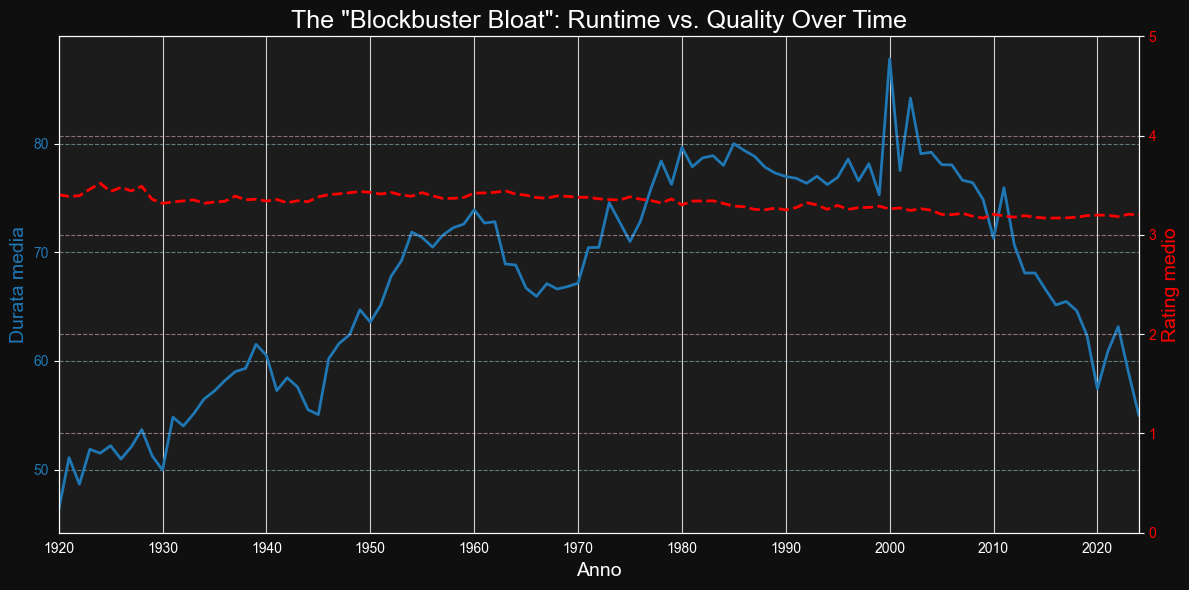

In [42]:
fig, ax1 = plt.subplots(figsize=(12, 6))

plt.plot()

ax1.plot(
    yearly_stats.index,
    yearly_stats['minute'],
    color='#1f77b4',
    linewidth=2,
    label='Durata'
)

fig.patch.set_facecolor('#0F0F0F')
ax1.set_facecolor('#1C1C1C')

ax1.xaxis.grid(True, color='white', linestyle='-', alpha=0.8)
ax1.yaxis.grid(True, color='lightblue', linestyle='--', alpha=0.5)

ax1.set_xlabel('Anno', fontsize=14)
ax1.set_ylabel('Durata media', color='#1f77b4', fontsize=14)
ax1.set_xlim(1920, 2024)
ax1.set_xticks(np.arange(1920, 2024, 10))

ax1.tick_params(axis='y', labelcolor='#1f77b4')


ax2 = ax1.twinx()

ax2.set_ylabel('Rating medio', color='red', fontsize=14)
ax2.plot(
    yearly_stats.index,
    yearly_stats['rating'],
    color='red',
    linewidth=2,
    linestyle='--',
    label='Rating'
)

ax2.tick_params(axis='y', labelcolor='red')
ax2.yaxis.grid(True, color='#ffcccc', linestyle='--', alpha=0.5)

ax2.set_ylim(0, 5)

plt.title('The "Blockbuster Bloat": Runtime vs. Quality Over Time', fontsize=18, color='white')
fig.tight_layout()

plt.show()

risultati

## Analisi due

In [43]:
df_map_data = pd.merge(
    df_countries[['id_film', 'country']],
    df_movies[['id_film', 'rating']],
    on='id_film'
)

country_means = df_map_data.groupby('country')['rating'].agg(['mean', 'count']).reset_index()

country_means.columns = ['country', 'rating', 'Movie_Count']

# Mappa di Paesi che non esistono più
country_patch = {
    'East Germany': 'Germany',
    'USSR': 'Russia',
    'Yugoslavia': 'Serbia',
    'Serbia and Montenegro': 'Serbia',
    'Netherlands Antilles': 'Netherlands'
}

country_means['country'] = country_means['country'].replace(country_patch)

# Usiamo una libreria per convertire i nomi dei Paesi in ISO3
cc = coco.CountryConverter()
country_means['iso'] = cc.convert(names=country_means['country'], to='ISO3')

fig = px.choropleth(
    country_means,
    locations="iso",
    locationmode="ISO-3",
    color="rating",
    hover_name="country",
    color_continuous_scale="Viridis",
    title="Rating Medio per Paese"
)
fig.show()

## analisu 3 "The Popcorn Gap" (Critics vs. Audience)


In [44]:
df_tomatoes_merge = df_tomatoes.copy()
df_movies_merge = df_movies.copy()

df_tomatoes_merge['match_title'] = df_tomatoes_merge['movie_title'].str.lower().str.strip()
df_movies_merge['match_title'] = df_movies_merge['name'].str.lower().str.strip()

clean_reviews = df_tomatoes_merge[df_tomatoes['score'] != -1].copy()

clean_movies = df_movies_merge[df_movies['date'].notna()].copy()


reviews_with_date = pd.merge(
    clean_reviews[['match_title', 'score', 'top_critic']],
    df_movies_merge[['match_title', 'date']],
    on='match_title',
    how='inner'
)

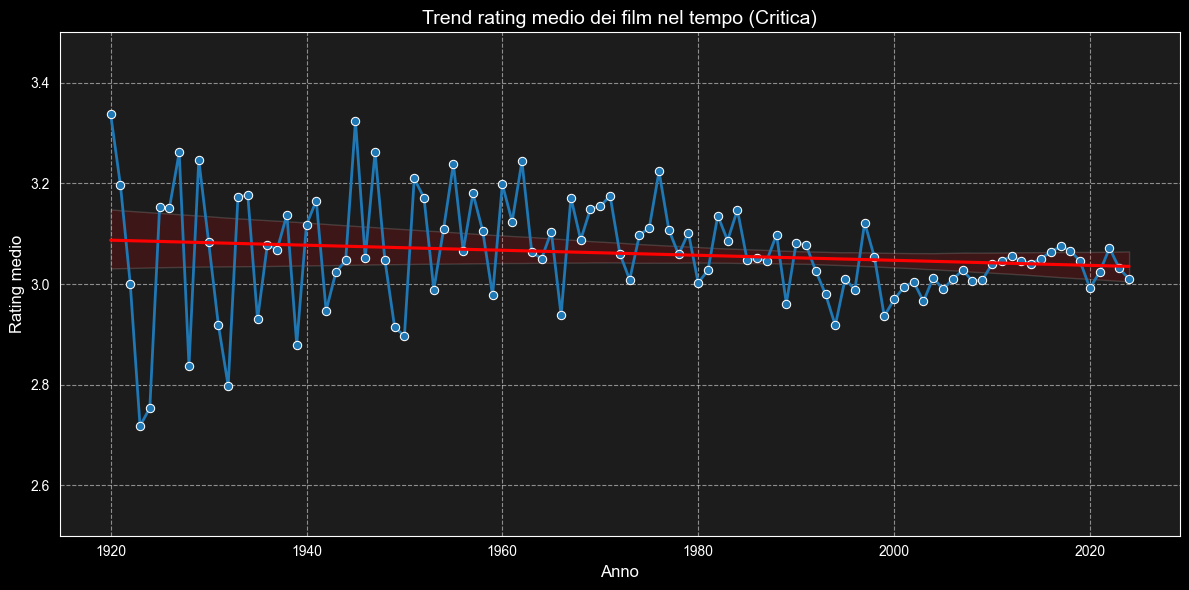

In [45]:
top_trend = reviews_with_date[reviews_with_date['top_critic'] == True].groupby('date')['score'].mean().reset_index()
top_trend = top_trend[(top_trend['date'] >= 1920) & (top_trend['date'] <= 2024)]

plt.figure(figsize=(12,6))
sns.lineplot(
    data=top_trend,
    x='date',
    y='score',
    marker='o',
    linewidth=2,
    color='#1f77b4'
)

sns.regplot(
    x=top_trend['date'],
    y=top_trend['score'],
    scatter=False,
    color="red",
    label="Trend"
)
plt.title("Trend rating medio dei film nel tempo (Critica)", fontsize=14)
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Rating medio", fontsize=12)
plt.ylim(2.5, 3.5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().set_facecolor('#1C1C1C')

plt.tight_layout()
plt.show()

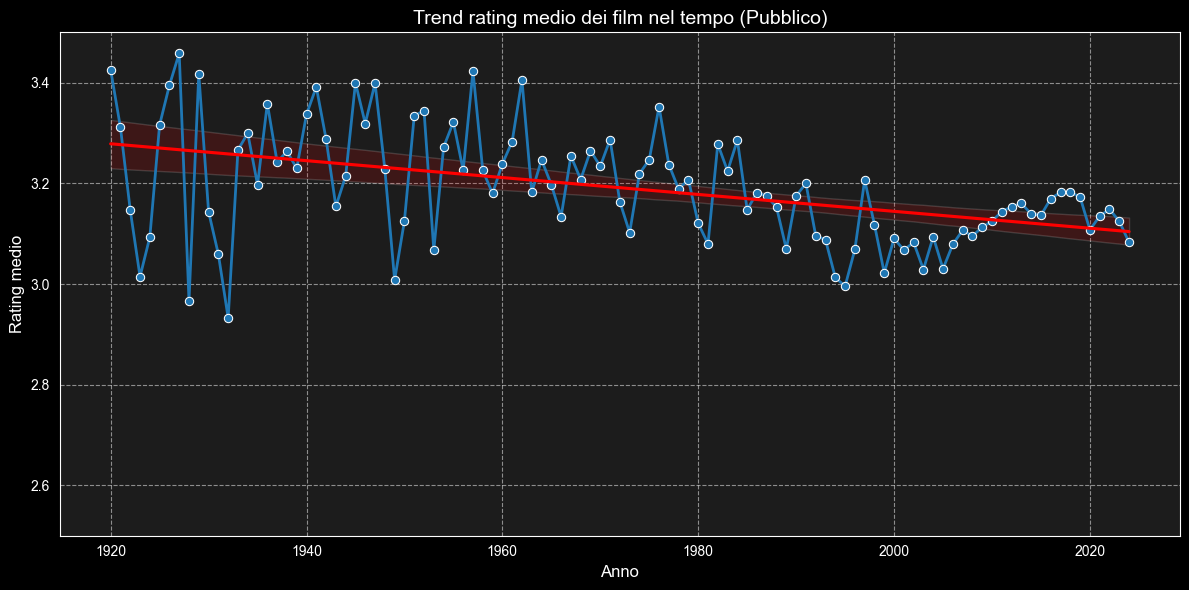

In [46]:
public_trend = reviews_with_date[reviews_with_date['top_critic'] == False].groupby('date')['score'].mean().reset_index()
public_trend = public_trend[(public_trend['date'] >= 1920) & (public_trend['date'] <= 2024)]

plt.figure(figsize=(12,6))
sns.lineplot(
    data=public_trend,
    x='date',
    y='score',
    marker='o',
    linewidth=2,
    color='#1f77b4'
)

sns.regplot(
    x=public_trend['date'],
    y=public_trend['score'],
    scatter=False,
    color="red",
    label="Trend"
)
plt.title("Trend rating medio dei film nel tempo (Pubblico)", fontsize=14)
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Rating medio", fontsize=12)
plt.ylim(2.5, 3.5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().set_facecolor('#1C1C1C')

plt.tight_layout()
plt.show()

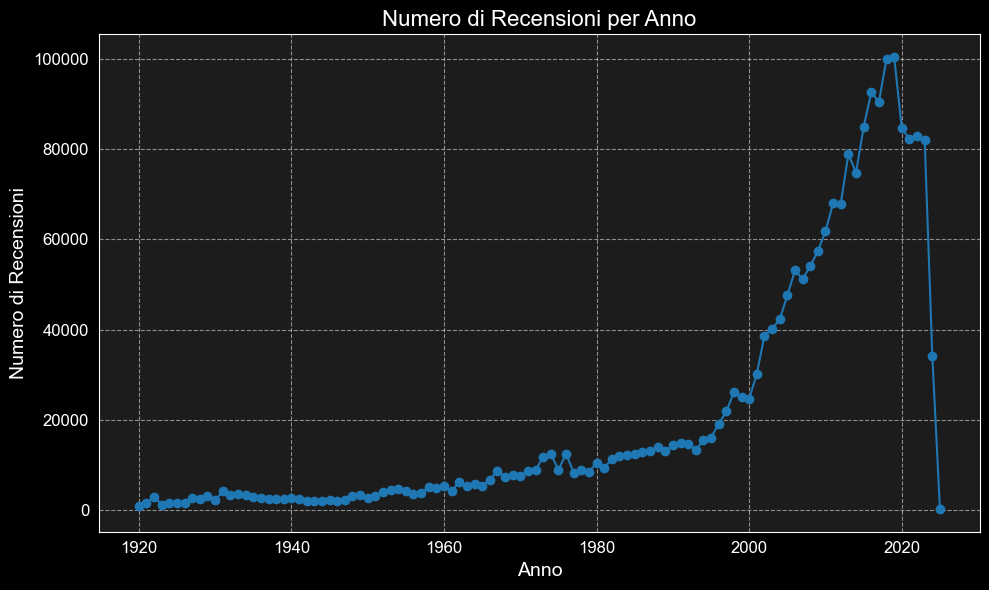

In [47]:
reviews_per_year = reviews_with_date.groupby('date').size()
reviews_per_year = reviews_per_year[reviews_per_year.index >= 1920]

plt.figure(figsize=(10, 6))

plt.plot(
    reviews_per_year.index,
    reviews_per_year.values,
    marker='o',
    linestyle='-',
    color='#1f77b4',
    label="Numero di Recensioni")

plt.title("Numero di Recensioni per Anno", fontsize=16)
plt.xlabel("Anno", fontsize=14)
plt.ylabel("Numero di Recensioni", fontsize=14)
plt.xticks(fontsize=12)


plt.yticks(fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().set_facecolor('#1C1C1C')
plt.tight_layout()
plt.show()

In [48]:
df_tomatoes_merge['is_fresh'] = df_tomatoes_merge['review_type'].apply(lambda x: 1 if x == 'Fresh' else 0)

top_critics = df_tomatoes_merge[df_tomatoes_merge['top_critic'] == True]

critic_consensus = top_critics.groupby('match_title')['is_fresh'].mean().reset_index()
critic_consensus.columns = ['match_title', 'critic_pct']

df_gap_real = pd.merge(df_movies_merge, critic_consensus, on='match_title', how='inner')

# Normalize Audience Rating (1-5 -> 0-100)
df_gap_real['audience_score_norm'] = (df_gap_real['rating'] / 5) * 100

# Normalize Critic Score (0.0-1.0 -> 0-100)
df_gap_real['critic_score_norm'] = df_gap_real['critic_pct'] * 100

# Calculate the Gap
df_gap_real['gap'] = df_gap_real['audience_score_norm'] - df_gap_real['critic_score_norm']

df_sample = df_gap_real.sample(n=1000, random_state=42)

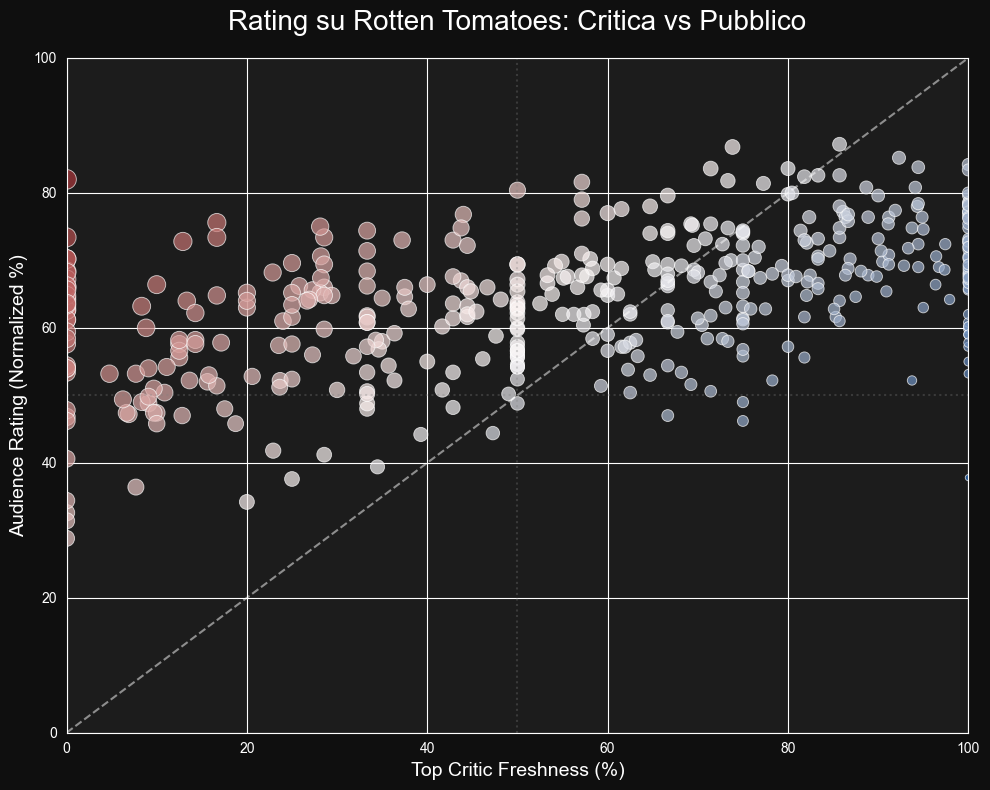

In [49]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0F0F0F')
ax.set_facecolor('#1C1C1C')

sns.scatterplot(
    data=df_sample,
    x='critic_score_norm',
    y='audience_score_norm',
    hue='gap',
    palette='vlag',
    size='gap',
    sizes=(20, 200),
    alpha=0.7,
    ax=ax,
    legend=False
)
ax.plot([0, 100], [0, 100], color='white', linestyle='--', alpha=0.5) # Perfect Agreement
ax.axhline(50, color='gray', linestyle=':', alpha=0.3)
ax.axvline(50, color='gray', linestyle=':', alpha=0.3)

ax.set_title('Rating su Rotten Tomatoes: Critica vs Pubblico', fontsize=20, color='white', pad=20)
ax.set_xlabel('Top Critic Freshness (%)', fontsize=14, color='white')
ax.set_ylabel('Audience Rating (Normalized %)', fontsize=14, color='white')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## ANALISI 4

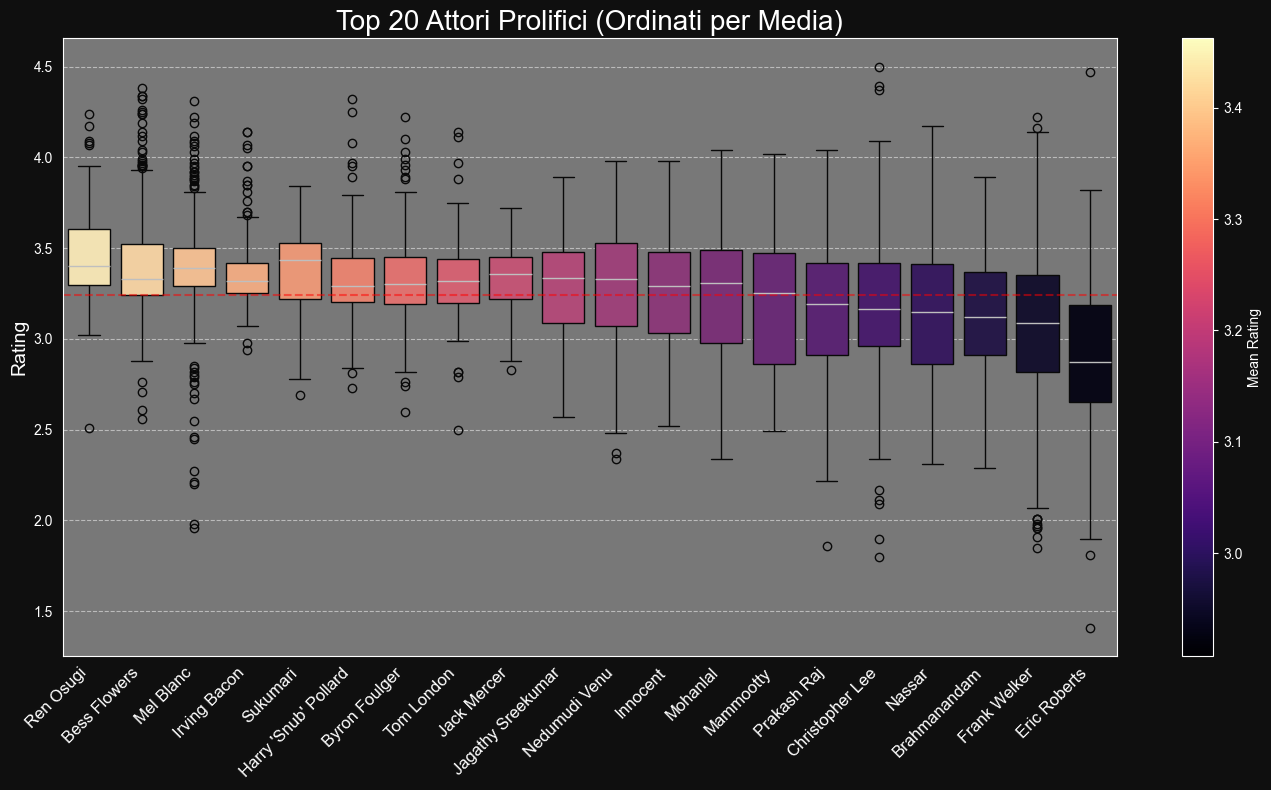

In [50]:
df_actor_ratings = pd.merge(
    df_movies[['id_film', 'rating']],
    df_actors[['id_film', 'name']],
    on='id_film',
    how='inner'
)
top_stars = df_actor_ratings['name'].value_counts().nlargest(20).index
df_stars = df_actor_ratings[df_actor_ratings['name'].isin(top_stars)]

# Ordiniamo in modo crescente, 'magma' va ds scuro a chiaro
actor_order_asc = df_stars.groupby('name')['rating'].mean().sort_values(ascending=True).index
actor_order_desc = actor_order_asc[::-1] #invertiamo (migliore a sinistra)

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 8), facecolor='#0F0F0F')
ax.set_facecolor('#787878')

sns.boxplot(
    data=df_stars,
    x='name',
    y='rating',
    order=actor_order_desc,
    hue_order=actor_order_desc,
    palette='magma_r',
    hue='name',
    legend=False,
    ax=ax,
    medianprops=dict(color='#BFBFBF')
)

# Linea per riferimento
ax.axhline(df_movies['rating'].mean(), color='red', linestyle='--', alpha=0.5, label='Global Avg')

# Normalizzazione della media
norm = plt.Normalize(
    df_stars.groupby('name')['rating'].mean().min(),
    df_stars.groupby('name')['rating'].mean().max()
)
sm = cm.ScalarMappable(cmap='magma', norm=norm)
cbar = plt.colorbar(sm, ax=ax)

cbar.set_label('Mean Rating', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.title('Top 20 Attori Prolifici (Ordinati per Media)', fontsize=20, color='white')
plt.xlabel('')
plt.ylabel('Rating', fontsize=14, color='white')
plt.xticks(rotation=45, ha='right', fontsize=12, color='white')
plt.yticks(color='white')
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

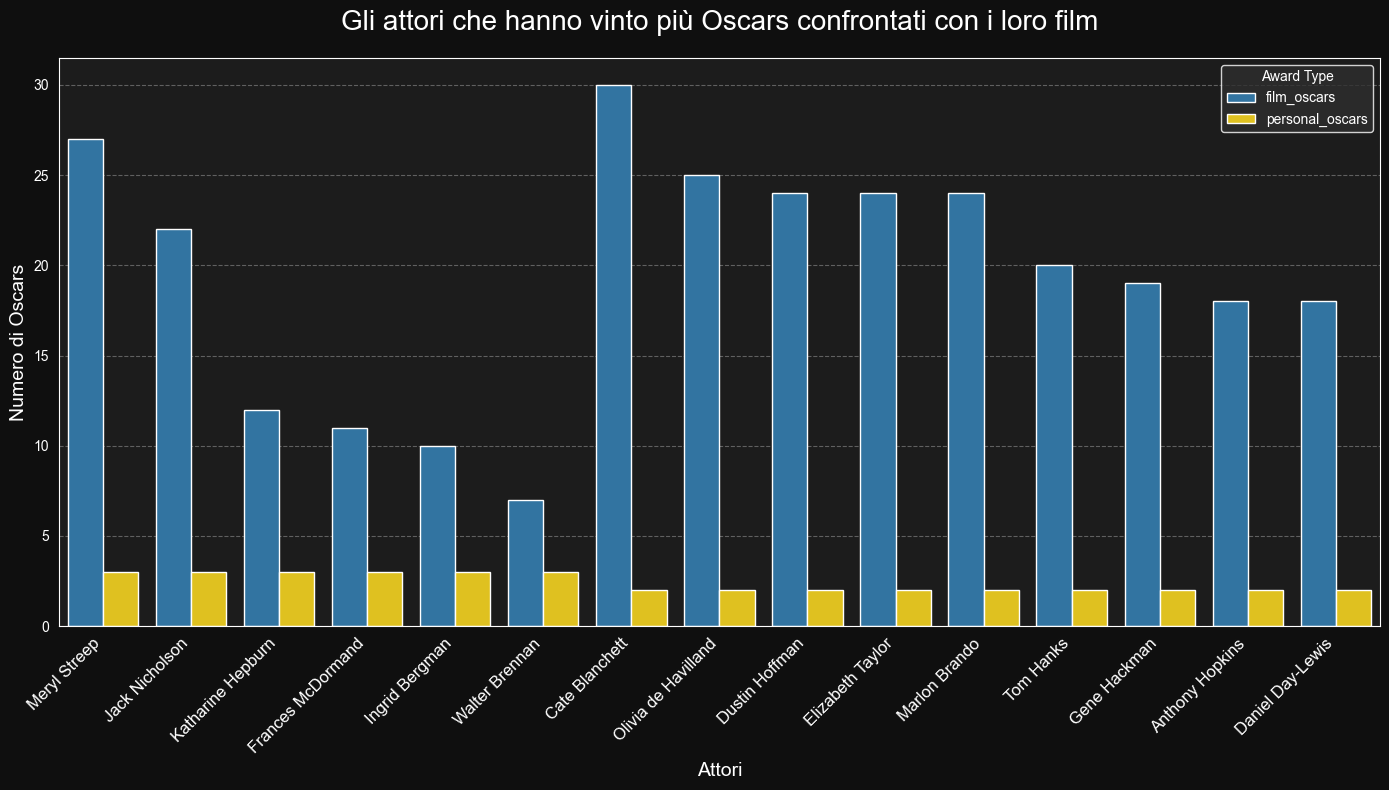

In [51]:
df_oscars_merge = df_oscars.copy()
df_oscars_merge['match_title'] = df_oscars_merge['film'].astype(str).str.lower().str.strip()
df_movies['match_title'] = df_movies['name'].astype(str).str.lower().str.strip()

oscars_won = df_oscars_merge[df_oscars_merge['winner'] == True].copy()

merged_data = pd.merge(
    oscars_won,
    df_movies[['match_title', 'id_film', 'date']],
    left_on=['match_title', 'year_film'],
    right_on=['match_title', 'date'],
    how='inner'
)
merged_data = pd.merge(merged_data, df_actors[['id_film', 'name']], on='id_film', how='inner')
# Questo creerà due versioni di name: 'name_x' e 'name_y' rispettivamente df_movies['name'] e df_actors['name']

# A noi interessa il 'name' dell attore
film_oscar_counts = merged_data.groupby('name_y').size().reset_index(name='film_oscars')

personal_wins = merged_data[
    merged_data['category'].str.contains('ACTOR|ACTRESS', case=False, na=False) &
    (merged_data['name_x'] == merged_data['name_y'])
]

personal_oscar_counts = personal_wins.groupby('name_y').size().reset_index(name='personal_oscars')

df_comparison = pd.merge(film_oscar_counts, personal_oscar_counts, on='name_y', how='left').fillna(0)

df_comparison.rename(columns={'name_y': 'name'}, inplace=True)

top_legends = df_comparison.sort_values(by=['personal_oscars', 'film_oscars'], ascending=False).head(15)

df_melted = top_legends.melt(id_vars='name', var_name='Type', value_name='Count')

plt.style.use('dark_background')
plt.figure(figsize=(14, 8), facecolor='#0F0F0F')
ax = plt.gca()
ax.set_facecolor('#1C1C1C')

sns.barplot(
    data=df_melted,
    x='name',
    y='Count',
    hue='Type',
    palette={'film_oscars': '#1f77b4', 'personal_oscars': '#ffd700'}, # Blue vs Gold
    ax=ax
)

plt.title('Gli attori che hanno vinto più Oscars confrontati con i loro film', fontsize=20, color='white', pad=20)
plt.xlabel('Attori', fontsize=14, color='white')
plt.ylabel('Numero di Oscars', fontsize=14, color='white')
plt.xticks(rotation=45, ha='right', fontsize=12, color='white')
plt.yticks(color='white')
plt.legend(title='Award Type', facecolor='#2E2E2E', edgecolor='white', labelcolor='white')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

menzionare la roba delle comparse

## ANALISI 5

In [52]:
# Variazione di "Miglior Film" nel tempo
best_picture_categories = [
    'BEST PICTURE',
    'BEST MOTION PICTURE',
    'OUTSTANDING PICTURE',
    'OUTSTANDING PRODUCTION',
    'OUTSTANDING MOTION PICTURE',
    'UNIQUE AND ARTISTIC PICTURE'
]

df_bp_winners = df_oscars[
    (df_oscars['category'].isin(best_picture_categories)) &
    (df_oscars['winner'] == True)
][['film', 'year_film', 'winner']]

df_bp_winners = df_bp_winners.rename(columns={
    'film': 'name',
    'year_film': 'date',
    'winner': 'won_best_picture'
})

df_bp_winners['date'] = df_bp_winners['date'].astype(int)
df_bp_winners['name'] = df_bp_winners['name'].astype(str).str.lower().str.strip()

df_trend['date'] = df_trend['date'].fillna(0).astype(int)
df_trend['name'] = df_movies['name'].astype(str).str.lower().str.strip()

df_final = pd.merge(df_trend, df_bp_winners, on=['name', 'date'], how='left')

df_final['won_best_picture'] = df_final['won_best_picture'].fillna(0).astype(int)

# Togliamo i cortometraggi (<52m) e film senza "rating"
df_clean = df_final[
    (df_final['minute'] >= 52) &
    (df_final['minute'] <= 240) &
    (df_final['rating'].notna())
].copy()

# Mappa per la Legenda
df_clean['Status'] = df_clean['won_best_picture'].map({1: 'Oscar Winner', 0: 'Standard Film'})

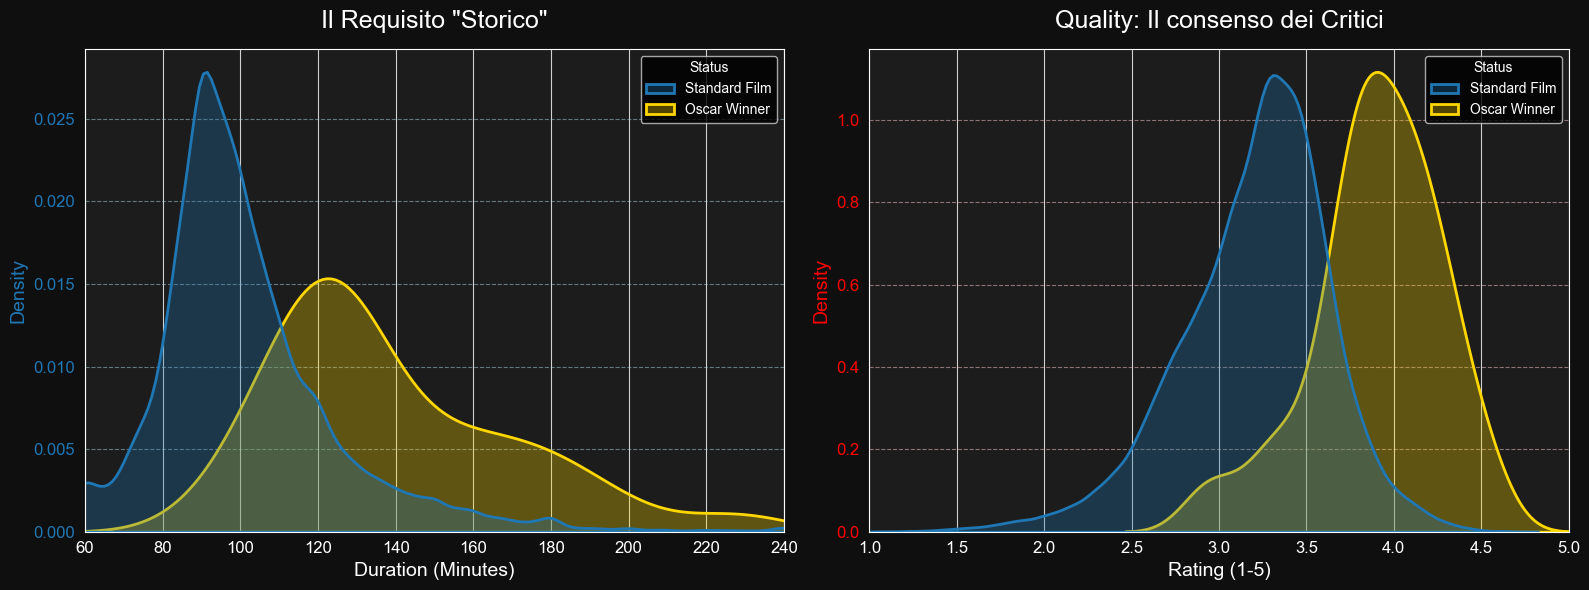

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.patch.set_facecolor('#0F0F0F')

my_palette = {'Oscar Winner': '#FFD700', 'Standard Film': '#1f77b4'}

ax1 = axes[0]
ax1.set_facecolor('#1C1C1C')

sns.kdeplot(
    data=df_clean,
    x='minute',
    hue='Status',
    palette=my_palette,
    fill=True,
    common_norm=False,
    alpha=0.3,
    linewidth=2,
    warn_singular=False,
    ax=ax1
)

ax1.set_title('Il Requisito "Storico"', fontsize=18, color='white', pad=15)
ax1.set_xlabel('Duration (Minutes)', fontsize=14, color='white')
ax1.set_ylabel('Density', fontsize=14, color='#1f77b4') # Blue Label
ax1.set_xlim(60, 240)

ax1.xaxis.grid(True, color='white', linestyle='-', alpha=0.8)
ax1.yaxis.grid(True, color='lightblue', linestyle='--', alpha=0.5)
ax1.tick_params(axis='x', colors='white', labelsize=12)
ax1.tick_params(axis='y', colors='#1f77b4', labelsize=12)

ax2 = axes[1]
ax2.set_facecolor('#1C1C1C')

sns.kdeplot(
    data=df_clean,
    x='rating',
    hue='Status',
    palette=my_palette,
    fill=True,
    common_norm=False,
    alpha=0.3,
    linewidth=2,
    warn_singular=False,
    ax=ax2
)

ax2.set_title('Quality: Il consenso dei Critici', fontsize=18, color='white', pad=15)
ax2.set_xlabel('Rating (1-5)', fontsize=14, color='white')
ax2.set_ylabel('Density', fontsize=14, color='red') # Red Label
ax2.set_xlim(1, 5)

ax2.xaxis.grid(True, color='white', linestyle='-', alpha=0.8)
ax2.yaxis.grid(True, color='#ffcccc', linestyle='--', alpha=0.5)
ax2.tick_params(axis='x', colors='white', labelsize=12)
ax2.tick_params(axis='y', colors='red', labelsize=12)


if ax1.get_legend():
    plt.setp(ax1.get_legend().get_texts(), color='white')
    plt.setp(ax1.get_legend().get_title(), color='white')
if ax2.get_legend():
    plt.setp(ax2.get_legend().get_texts(), color='white')
    plt.setp(ax2.get_legend().get_title(), color='white')

plt.tight_layout()
plt.show()

spiegare la densita

## ANALISI 6

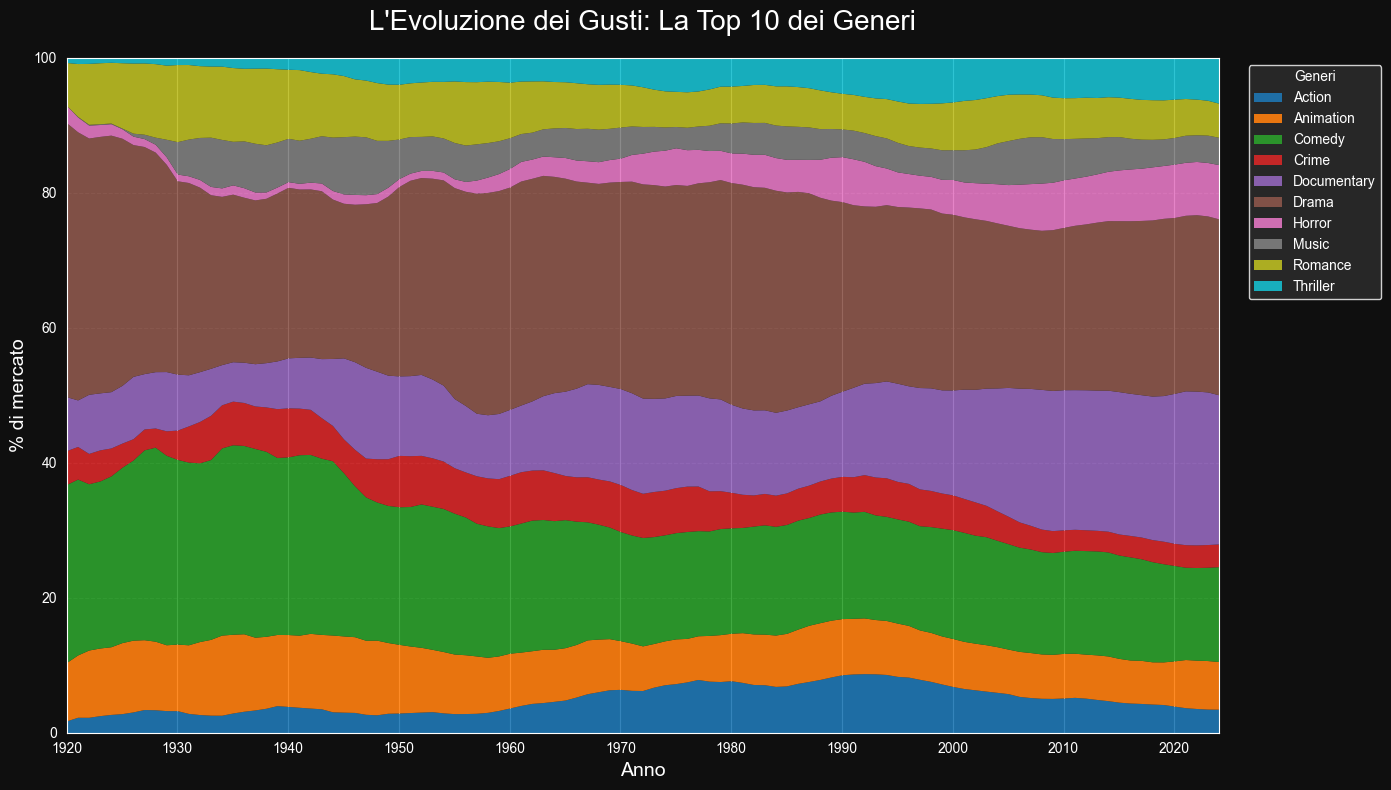

In [54]:
df_merged = pd.merge(
    df_movies[['id_film', 'date']],
    df_genres[['id_film', 'genre']],
    on='id_film',
    how='inner'
)
df_merged = df_merged[(df_merged['date'] >= 1920) & (df_merged['date'] <= 2024)]

top_genres = df_merged['genre'].value_counts().nlargest(10).index.tolist()
filtered_data = df_merged[df_merged['genre'].isin(top_genres)]

genre_counts = pd.crosstab(filtered_data['date'], filtered_data['genre'])

# Normalizzando in Percentuale
genre_share = genre_counts.div(genre_counts.sum(axis=1), axis=0) * 100

# Appiattimento raggruppando i rating ogni 5 anni
genre_share_smooth = genre_share.rolling(window=5, min_periods=1).mean()

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 8), facecolor='#0F0F0F')
ax.set_facecolor('#1C1C1C')

# 'tab10' 10 colori per 10 categorie
genre_share_smooth.plot.area(ax=ax, cmap='tab10', alpha=0.9, linewidth=0)

plt.title('L\'Evoluzione dei Gusti: La Top 10 dei Generi', fontsize=20, color='white', pad=20)
plt.xlabel('Anno', fontsize=14, color='white')
plt.ylabel('% di mercato', fontsize=14, color='white')

plt.xlim(1920, 2024)
plt.ylim(0, 100)
ax.set_xticks(np.arange(1920, 2024, 10))

plt.legend(title='Generi', bbox_to_anchor=(1.02, 1), loc='upper left',
           facecolor='#2E2E2E', edgecolor='white', labelcolor='white')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

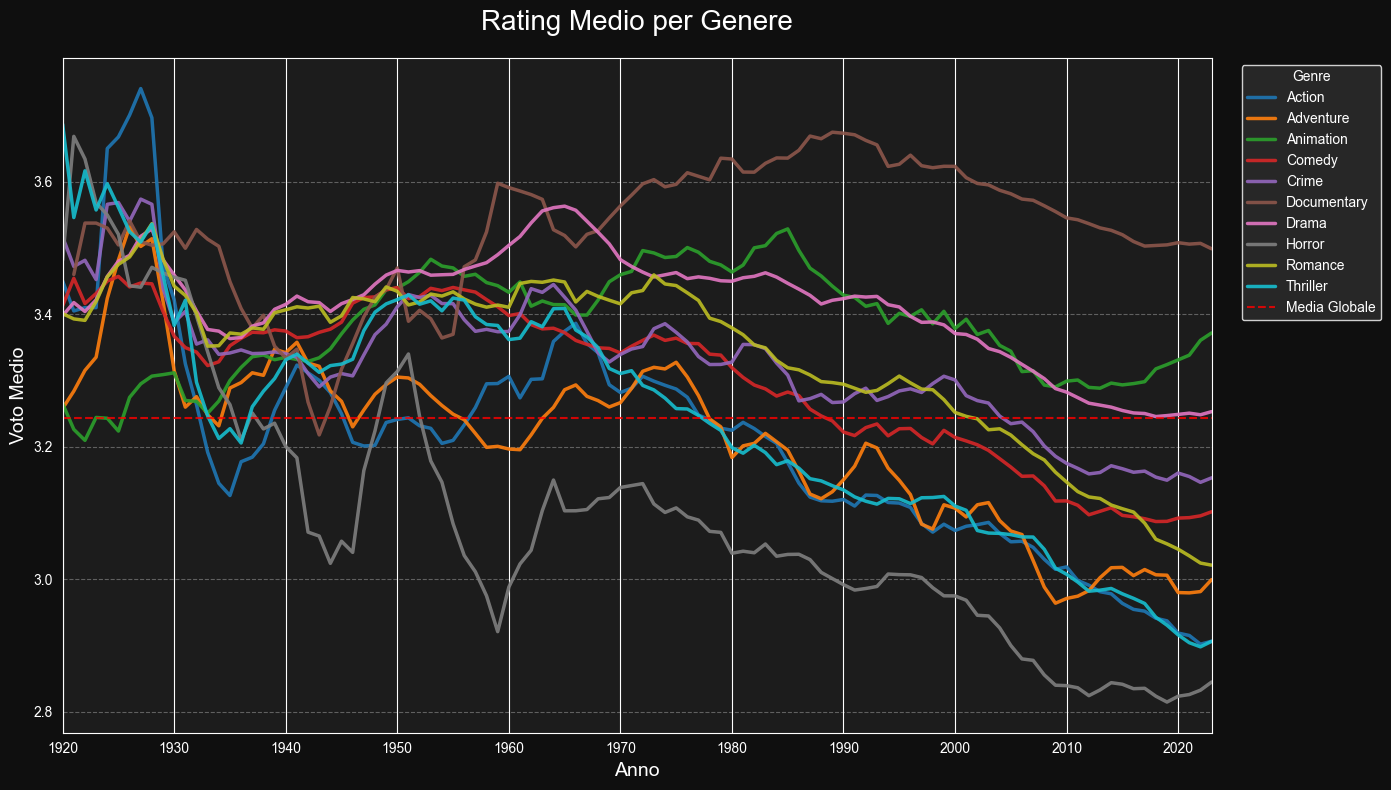

In [55]:
df_merged = pd.merge(
    df_movies[['id_film', 'date', 'rating']], 
    df_genres[['id_film', 'genre']], 
    on='id_film', 
    how='inner'
)

df_merged = df_merged[(df_merged['date'] >= 1920) & (df_merged['date'] <= 2023)]
df_merged = df_merged.dropna(subset=['rating'])

# Come prima teniamo i top 10 generi
top_genres = df_merged['genre'].value_counts().nlargest(10).index.tolist()
filtered_quality = df_merged[df_merged['genre'].isin(top_genres)]

genre_ratings = filtered_quality.groupby(['date', 'genre'])['rating'].mean().unstack()

# Appiattimento dei rating a gruppi di 5 anni
genre_ratings_smooth = genre_ratings.rolling(window=5, min_periods=1).mean()

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 8), facecolor='#0F0F0F')
ax.set_facecolor('#1C1C1C')

# Stesso cmap (tab10) per avere gli stessi colori
genre_ratings_smooth.plot(ax=ax, cmap='tab10', linewidth=2.5, alpha=0.9)

plt.title('Rating Medio per Genere', fontsize=20, color='white', pad=20)
plt.xlabel('Anno', fontsize=14, color='white')
plt.ylabel('Voto Medio', fontsize=14, color='white')

global_avg = df_movies['rating'].mean()
plt.axhline(global_avg, color='red', linestyle='--', alpha=0.8, label='Media Globale')

plt.xlim(1920, 2023)
ax.set_xticks(np.arange(1920, 2024, 10))

plt.legend(title='Genre', bbox_to_anchor=(1.02, 1), loc='upper left',
           facecolor='#2E2E2E', edgecolor='white', labelcolor='white')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()